In [3]:
quiet_library <- function(...){suppressPackageStartupMessages(library(...))}
quiet_library(dplyr)
quiet_library(purrr)
quiet_library(tidyr)
quiet_library(data.table)
quiet_library(ggplot2)
quiet_library(glue)
quiet_library(gridExtra)
quiet_library(grid)
quiet_library(clusterProfiler)
quiet_library(BaseSet)
quiet_library(jsonlite)
quiet_library(rrvgo)
quiet_library(eulerr)

options(repr.matrix.max.cols=150, repr.matrix.max.rows=200, mc.cores = 20, future.globals.maxSize = 2000 * 1024^2)
fig.size <- function (height, width) {
    options(repr.plot.height = height, repr.plot.width = width)
}

In [4]:
wd <- "/home/workspace/IFN"
fig_dir <- file.path(wd, "Figures")

In [5]:
set.seed(123)

In [6]:
stims <- c("IFNa", "IFNb", "IFN-L1", "IFNg")
celltypes <- c("Bcell", "Tcell", "NK", "Monocyte")
subtypes <- c("CD4 Naive", "CD4 Memory", "Treg", "CD8 Naive", "CD8 Memory", "MAIT", "gdT", 
              "B Naive", "B Memory", "Plasma", 
              "NK.CD56hi", "NK.CD56dim", 
              "CD14 Monocyte")
celltype_cols <- c("#00b4d8", "#1b4332", "#ffbf69", "#78290f" )
subtype_cols <- c("#03045e", "#023e8a", "#0077b6", "#0096c7", "#00b4d8", "#48cae4", "#90e0ef",
                   "#1b4332", "#52b788", "#b7e4c7",
                    "#ff9f1c", "#ffbf69", 
                   "#78290f"
                  )
stim_cols <- c("#e9c46a", "#f4a261", "#e76f51", "#264653", "#2a9d8f")

### 4A. Donor Level IFNg Specific DEGs Heatmap

In [26]:
donor_degs <- fread(file.path(wd, "DEGs", "Donor_Level_IFNg_DEGs_Sup4a.csv"))

In [27]:
stim_select <- "IFNa"

In [28]:
mat <- donor_degs %>% 
        mutate(Celltype_Donor = paste(Celltype, Donor, sep = "_")) %>% 
        select(gene, Celltype_Donor, iteration_median_log2FC) %>% 
        pivot_wider(names_from = Celltype_Donor, values_from = iteration_median_log2FC) %>% 
        tibble::column_to_rownames("gene") %>% as.matrix()
mat[is.na(mat)] <- 0

In [29]:
meta <- donor_degs %>% select(Celltype) %>% unique
meta <- data.frame(Celltype = rep(celltypes, each = 5))
HA <- ComplexHeatmap::HeatmapAnnotation(df = meta %>% select(Celltype), 
                                        col = list(Celltype = c("Tcell" = "#00b4d8",
                                                                "Bcell" = "#1b4332",
                                                                "NK" = "#ffbf69",
                                                                "Monocyte" = "#78290f"
                  )))

In [30]:
# IFNg
top_degs <- c(
  "VRK2",
  "TCIRG1",
  "RAC2",
  "ITGA4",
  "CALHM6",
  "SERPING1",
  "CXCL11",
  "SNX10"
)


null device 
          1

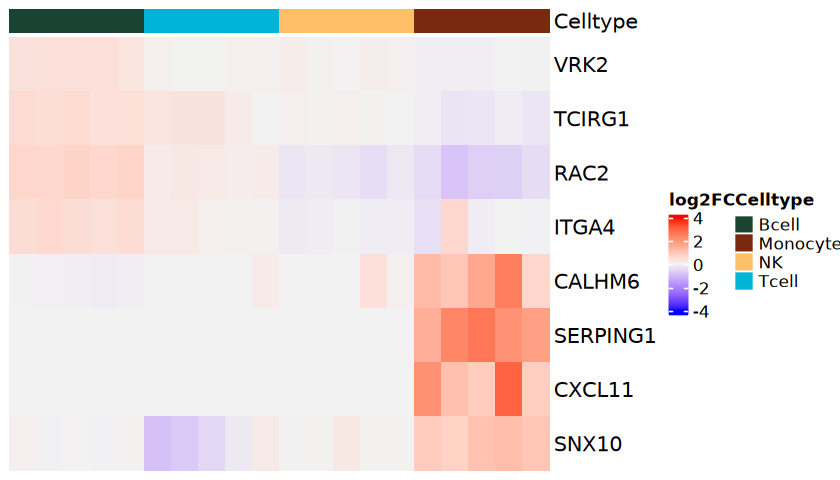

In [31]:
fig.size(4,7)
#pdf(file.path(fig_dir, "Supp", "Sup4", glue("{stim_select}_Unique_Genes_Donor_Heatmap.pdf")), 
#    height = 4, width = 7)
col_fun <- circlize::colorRamp2(c(-4, 0, 4), c("blue", "gray95", "red"))
ComplexHeatmap::Heatmap(mat[top_degs,], name = "log2FC", top_annotation = HA, 
                        show_row_names = T, show_column_names = F, col = col_fun, 
                        #column_split = factor(rep(stims, each = 5), levels = stims),
                        cluster_columns = F, 
                        cluster_column_slices = F, cluster_rows = F,
                        #clustering_distance_rows = "manhattan",
                        column_title_rot = 90
                        ) 
dev.off()

### 4B. IFNg L1 Upset GOBP Pathway Enrichment Heatmap

In [3]:
database <- "GO_BP"
stim <- "IFNg"

In [9]:
# read in GO BP pathways GMT
gs <- getGMT(file.path(wd, "msigdb_v2024.1.Hs", "msigdb_v2024.1.Hs_GMTs", "c5.go.bp.v2024.1.Hs.symbols.gmt"))
select_sets <- data.frame(
            gs_name = gs@relations$sets,
          gene_symbol = gs@relations$elements)

In [10]:
# mapping of gene IDs to symbols
json <- fromJSON(file.path(wd, "msigdb_v2024.1.Hs", "msigdb_v2024.1.Hs_json_files_to_download_locally", "c5.go.bp.v2024.1.Hs.json"), 
                 flatten = TRUE)

df <- do.call(rbind, json) %>% as.data.frame()
df$gs_name <- rownames(df)

select_sets <- select_sets %>% left_join(df)
name_to_id <- select_sets %>% select(gs_name, exactSource) %>% unique()

Joining with `by = join_by(gs_name)`


In [13]:
# load upset dataframe and convert to list
upset_df <- fread(glue(file.path(wd, "DEGs", "Pathways", "{stim}_Upset", "Upset_{stim}_DF.csv")))
res <- split(upset_df$gene, upset_df$set)

In [ ]:
# iterate over gene list in each upset plot set
setnames <- names(res)
for (x in seq_along(res)){

    setname <- setnames[[x]]
    print(setname)
    
    # split by up and down-regulated genes
    for (direction in c("Upreg", "Downreg")){
         
        if (direction == "Upreg"){regex = "^\\+"} else {regex = "^\\-"}
        genes_select <- res[[x]][grep(regex, res[[x]])]  %>% sub("^[+-]", "", .)
    
        if (length(genes_select) > 5){
           
            enriched <- enricher(genes_select, TERM2GENE = select_sets)
            
            if (!is.null(enriched)){
                enriched <- enriched@result %>% filter(p.adjust < 0.05)
                
                # formatting 
                if (nrow(enriched) > 2){
                    enriched <- enriched %>% 
                                    left_join(name_to_id, by = c("ID" = "gs_name")) %>%
                                    mutate(ID = as.character(exactSource)) %>%
                                    mutate(Description = as.character(gsub("_", " ", tolower(enriched$Description)))) %>% 
                                    mutate(Description = gsub("gobp ", "", Description)) %>% 
                                    mutate(Description = gsub(" i ", " I ", Description)) %>% 
                                    mutate(Description = gsub(" ii ", " II ", Description))
    
                    # rrvgo reduction of overlapping pathways to parent terms
                    simMatrix <- calculateSimMatrix(enriched$ID,
                                    orgdb="org.Hs.eg.db",
                                    ont="BP",
                                    method="Rel")
                    
                    scores <- setNames(-log10(enriched$qvalue), enriched$ID)
                    reducedTerms <- reduceSimMatrix(simMatrix,
                                                    scores = "size",
                                                    threshold=0.5,
                                                    orgdb="org.Hs.eg.db")
                    
                    enriched %>% 
                        filter(Description %in% reducedTerms$parentTerm) %>% 
                        fwrite(file.path(wd, "DEGs", "Pathways", glue("{stim}_Upset"), database, glue("{setname}_{direction}_Enricher_rrvgo_collapsed_size.csv")))
                }
              }
            }  
        }
    }

In [15]:
# formatting of upset plot set names
setnames_final <- list.files(glue(file.path(wd, "DEGs", "Pathways", "{stim}_Upset", "{database}")), 
                             pattern = "rrvgo_collapsed_size") %>% 
    sub("_Enricher_rrvgo.*", "", .)

sorted_setnames <- setnames_final[grepl("Upreg", setnames_final)]
sorted_setnames <- c(sorted_setnames, setnames_final[grepl("Downreg", setnames_final)])

sorted_setnames

[1] "Bcell_Monocyte_Upreg"       "Bcell_Upreg"               
[3] "Monocyte_Upreg"             "Tcell_Bcell_Monocyte_Upreg"
[5] "Tcell_Bcell_Upreg"          "Monocyte_Downreg"

In [17]:
# get top pathways
pathways_df <- map_dfr(sorted_setnames, function(s){
        pathways <- fread(file.path(wd, "DEGs", "Pathways", glue("{stim}_Upset"), database, glue("{s}_Enricher_rrvgo_collapsed_size.csv"))) 
    
        if (nrow(pathways) > 0){
            pathways$set <- s
            pathways
            }
    })

top_pathways <- pathways_df %>% group_by(set) %>% slice_min(p.adjust, n = 5, with_ties = F) %>% 
    ungroup() %>% pull(Description) %>% unique()
pathways_df_filtered <- pathways_df %>% filter(Description %in% top_pathways) %>% select(set, Description, p.adjust)
sets <- pathways_df_filtered$set %>% unique

In [59]:
# save top five pathways as dataframe 
pathways_df %>% 
    filter(Description %in% top_pathways) %>% 
    fwrite(file.path(wd, "DEGs", "Pathways", glue("{stim}_Upset"), database, glue("{stim}_Upset_Enricher_pathways_top5.csv")))

In [18]:
# define all possible combinations of Subtype and Stim
all_combinations <- expand.grid(
  set = sets,
  Description = unique(top_pathways)
)


In [19]:
# add missing combinations and fill missing values with 0
df_complete <- all_combinations %>%
  left_join(pathways_df_filtered, by = c("set", "Description")) %>%
  mutate(p.adjust = ifelse(is.na(p.adjust), 0, p.adjust),
        log_pval = -log10(p.adjust))
df_complete$log_pval[is.infinite(df_complete$log_pval)] <- 0



In [20]:
df_complete$set <- factor(df_complete$set, levels = sorted_setnames)

null device 
          1

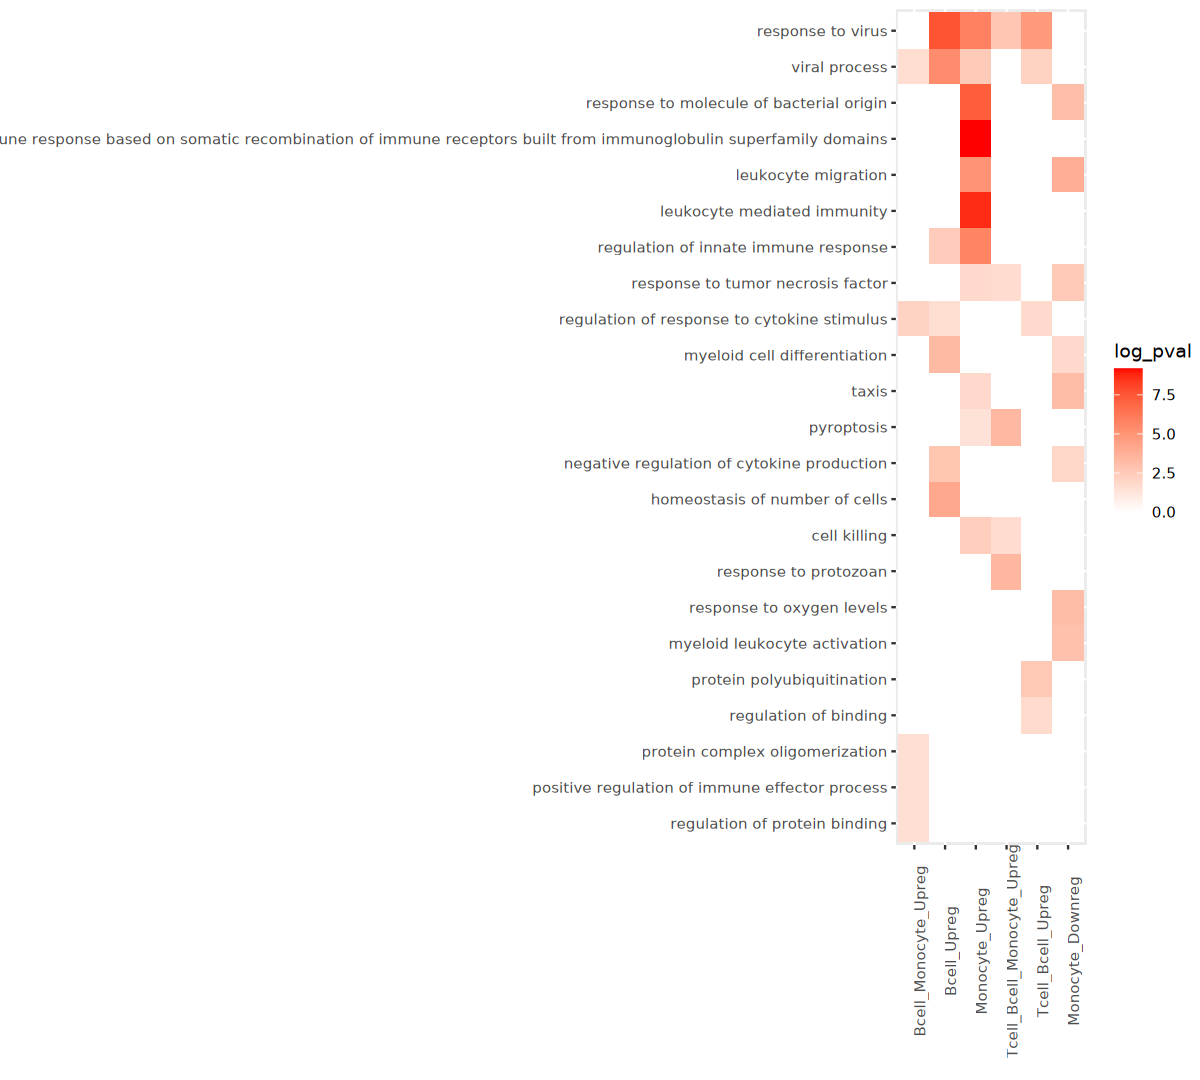

In [24]:
fig.size(9,10)
#pdf(file.path(fig_dir, "Supp", "Sup4", "IFNg_Upset_Plot_GOBP_Heatmap.pdf"), height = 9, width = 10)
ggplot(df_complete, aes(x = set, y = reorder(Description, log_pval), fill = log_pval)) + 
  geom_tile() +
  scale_fill_gradient(low="white", high="red") + 
    theme(axis.text.x = element_text(angle = 90)) + 
    labs(x = "", y = "") 

dev.off()

### 4C/D. IFNg L2 Celltype Venn Diagrams

In [25]:
# read in DEGs IFN results
l2_degs <- fread(file.path(wd, "DEGs", "L2_All_Celltypes_Stims_N1_DEGs.csv"))

#### B cell

In [26]:
subtypes_select <- c("B Naive", "B Memory", "Plasma")

ls_degs <- lapply(subtypes_select, function(x){
    l2_degs %>% filter(stim == "IFNg" & celltype == x & Significant == "Yes") %>% pull(gene) %>% unique()
    })
names(ls_degs) <- subtypes_select

null device 
          1

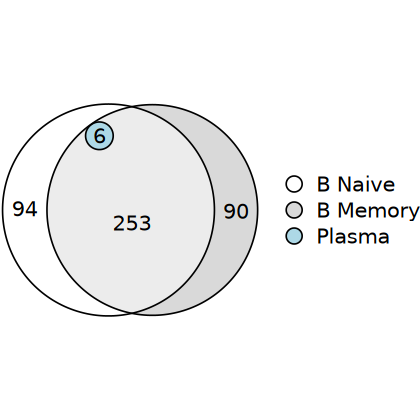

In [27]:
#pdf(file.path(fig_dir, "Supp", "Sup4", "IFNg_Bcell_Subsets_Venn_Diagram.pdf"), height = 3.5, width = 3.5)
fig.size(3.5,3.5)
plot(euler(ls_degs, shape = "ellipse"), quantities = TRUE, 
        #list(fill = cols, alpha = 1),
     legend = list(labels = c("B Naive", "B Memory", "Plasma")))
dev.off()

#### T cell

In [28]:
subtypes_select <- c("CD4 Naive", "CD4 Memory", "CD8 Naive", "Treg")

ls_degs <- lapply(subtypes_select, function(x){
    l2_degs %>% filter(stim == "IFNg" & celltype == x & Significant == "Yes") %>% pull(gene) %>% unique()
    })
names(ls_degs) <- subtypes_select

null device 
          1

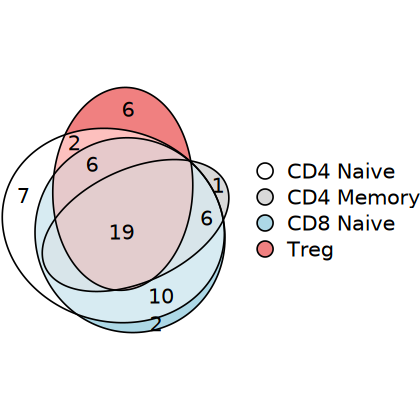

In [29]:
#pdf(file.path(fig_dir, "Supp", "Sup4", "IFNg_Tcell_Subsets_Venn_Diagram.pdf"), height = 3.5, width = 3.5)
fig.size(3.5,3.5)
plot(euler(ls_degs, shape = "ellipse"), quantities = TRUE, 
        #list(fill = cols, alpha = 1),
     legend = list(labels = c("CD4 Naive", "CD4 Memory", "CD8 Naive", "Treg")))
dev.off()